In [1]:
import os
import re
import glob
from IPython.display import display
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
#import japanize_matplotlib
import seaborn as sns 
import unicodedata
import yaml



In [2]:
# configの読み込み
CONFIG_FILE = '../configs/config.yaml'
with open(CONFIG_FILE, encoding="utf-8") as file:
    yml = yaml.safe_load(file)

In [3]:
DIR_INPUT = yml["SETTING"]["DIR_INPUT"]
DIR_INTERIM = yml["SETTING"]["DIR_INTERIM"]
DIR_FEATURE = yml["SETTING"]["DIR_FEATURE"]
DIR_FIGURE = yml["SETTING"]["DIR_FIGURE"]
DIR_HOME = yml["SETTING"]["DIR_HOME"]
DIR_LOG = yml["SETTING"]["DIR_LOG"]
DIR_SUBMISSION = yml["SETTING"]["DIR_SUBMISSION"]
FILE_NAME_STATION = yml["SETTING"]["FILE_NAME_STATION"]
FILE_NAME_STATUS = yml["SETTING"]["FILE_NAME_STATUS"]
FILE_NAME_TRIP = yml["SETTING"]["FILE_NAME_TRIP"]
FILE_NAME_WEATHER = yml["SETTING"]["FILE_NAME_WEATHER"]

# データ読み込み

In [14]:
dict_dtype_station = {
    "station_id": "int64",
    "lat": "float64",
    "long": "float64",
    "dock_count": "int64",
    "city": "object",
    "installation_date": "object",
}
dict_dtype_status = {
    "id": "int64",
    "year": "int64",
    "month": "int64",
    "day": "int64",
    "hour": "int64",
    "station_id": "int64",
    "bikes_available": "float64",
    "predict": "int64",
}
dict_dtype_trip = {
    "trip_id": "int64",
    "duration": "int64",
    "start_date": "object",
    "start_station_id": "int64",
    "end_date": "object",
    "end_station_id": "int64",
    "bike_id": "int64",
    "subscription_type": "object",
}
dict_dtype_weather = {
    "date": "object",
    "max_temperature": "int64",
    "mean_temperature": "int64",
    "min_temperature": "int64",
    "max_dew_point": "int64",
    "mean_dew_point": "int64",
    "min_dew_point": "int64",
    "max_humidity": "int64",
    "mean_humidity": "int64",
    "min_humidity": "int64",
    "max_sea_level_pressure": "float64",
    "mean_sea_level_pressure": "float64",
    "min_sea_level_pressure": "float64",
    "max_visibility": "int64",
    "mean_visibility": "int64",
    "min_visibility": "int64",
    "max_wind_Speed": "int64",
    "mean_wind_speed": "int64",
    "precipitation": "float64",
    "cloud_cover": "int64",
    "events": "object",
    "wind_dir_degrees": "int64",
}

In [15]:
df_station = pd.read_csv(os.path.join(DIR_INPUT, FILE_NAME_STATION), dtype=dict_dtype_station)
df_status = pd.read_csv(os.path.join(DIR_INPUT, FILE_NAME_STATUS), dtype=dict_dtype_status)
df_trip = pd.read_csv(os.path.join(DIR_INPUT, FILE_NAME_TRIP), dtype=dict_dtype_trip)
df_weather = pd.read_csv(os.path.join(DIR_INPUT, FILE_NAME_WEATHER), dtype=dict_dtype_weather)

# 前処理

In [16]:
def convert_datetime(df_station, df_status, df_trip, df_weather):
    df_station["installation_date"] = pd.to_datetime(df_station["installation_date"], format='%m/%d/%Y').dt.date
    df_status["datetime"] = pd.to_datetime(df_status[["year", "month", "day", "hour"]])
    df_trip["start_date"] = pd.to_datetime(df_trip["start_date"], format='%m/%d/%Y %H:%M')
    df_trip["end_date"] = pd.to_datetime(df_trip["end_date"], format='%m/%d/%Y %H:%M')
    df_weather["date"] = pd.to_datetime(df_weather["date"], format='%Y-%m-%d').dt.date

    return df_station, df_status, df_trip, df_weather

In [17]:
df_station, df_status, df_trip, df_weather = convert_datetime(df_station, df_status, df_trip, df_weather)

## データ出力

In [18]:
df_station.to_pickle(os.path.join(DIR_INTERIM, "df_prep_station.pkl"))
df_status.to_pickle(os.path.join(DIR_INTERIM, "df_prep_status.pkl"))
df_trip.to_pickle(os.path.join(DIR_INTERIM, "df_prep_trip.pkl"))
df_weather.to_pickle(os.path.join(DIR_INTERIM, "df_prep_weather.pkl"))

# 特徴量作成

In [19]:
from pathlib import Path
from abc import ABCMeta, abstractmethod

In [20]:
from time import time

def decorate(s: str, decoration=None):
    if decoration is None:
        decoration = '★' * 20
        
    return ' '.join([decoration, str(s), decoration])

class Timer:
    def __init__(self, logger=None, format_str='{:.3f}[s]', prefix=None, suffix=None, sep=' ', verbose=0):

        if prefix: format_str = str(prefix) + sep + format_str
        if suffix: format_str = format_str + sep + str(suffix)
        self.format_str = format_str
        self.logger = logger
        self.start = None
        self.end = None
        self.verbose = verbose

    @property
    def duration(self):
        if self.end is None:
            return 0
        return self.end - self.start

    def __enter__(self):
        self.start = time()

    def __exit__(self, exc_type, exc_val, exc_tb):
        self.end = time()
        if self.verbose is None:
            return
        out_str = self.format_str.format(self.duration)
        if self.logger:
            self.logger.info(out_str)
        else:
            print(out_str)

In [21]:
class AbstractBaseBlock(metaclass=ABCMeta):

    def __init__(self, use_cache=False, save_cache=False, logger=None):
        self.use_cache = use_cache
        self.name = self.__class__.__name__
        self.cache_dir = Path(DIR_FEATURE)
        self.logger = logger
        self.seve_cache = save_cache
        self.use_cols = None
        
    # 内部状態の更新
    def fit(self, df_input: pd.DataFrame, y=None):
        pass
    
    # 変換処理
    @abstractmethod
    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        raise NotImplementedError()
    
    # 内部状態の更新と変換処理をまとめて行う
    def fit_transform(self, X: pd.DataFrame, y=None):
        self.fit(X, y)
        return self.transform(X)
    
    # 特徴量生成処理
    def create_feature(self, X, y=None, test=False, limit_date="yyyy-mm-dd") -> pd.DataFrame:

        # クラス名.pkl
        file_name = os.path.join(self.cache_dir, limit_date, f"{self.name}.pkl")

        # キャッシュを使う & ファイルがあるなら読み出し
        if os.path.isfile(str(file_name)) and self.use_cache:
            return pd.read_pickle(file_name)
        
        # 変換処理を実行
        else:
            # trainの場合
            if not test:
                feature = self.fit_transform(X, y)
            # testの場合
            else:
                feature = self.transform(X)
            # 保存する場合
            if self.seve_cache:
                feature.to_pickle(file_name)

            return feature

In [22]:
# そのままの特徴量を返すBlock

In [23]:
# 静的特徴量
# 動的特徴量

In [24]:
class AsIsNumetricBlock(AbstractBaseBlock):

    def __init__(self, use_cache=False, save_cache=False, logger=None):
        super().__init__(use_cache, save_cache, logger)
        self.use_cols = [
            'CityTier', 
            'DurationOfPitch',
            'NumberOfPersonVisiting',
            'NumberOfFollowups', 
            'PreferredPropertyStar', 
            'NumberOfTrips',
            'Passport', 
            'PitchSatisfactionScore',
            'MonthlyIncome', 
            'ProdTaken' # 目的関数
        ]
        self.key_col = ["id"]
        self.map_count = None

    def transform(self, df_input):
        df_out = pd.DataFrame()
        df_out = df_input[self.key_col + self.use_cols]
        return df_out

class AsIsCategoryBlock(AbstractBaseBlock):

    def __init__(self, use_cache=False, save_cache=False, logger=None):
        super().__init__(use_cache, save_cache, logger)
        self.use_cols = [
            'Age', 
            'TypeofContact',
            'Occupation',
            'Gender',
            'ProductPitched',
            'Designation', 
            'customer_info', 
            'marry', 
            'car', 
            'child',
        ]
        self.key_col = ["id"]
        self.map_count = None

    def transform(self, df_input):
        df_out = pd.DataFrame()
        df_out = df_input[self.key_col + self.use_cols]
        return df_out

In [25]:
class CountEncodingBlock(AbstractBaseBlock):

    def __init__(self, use_cache=False, save_cache=False, logger=None):
        super().__init__(use_cache, save_cache, logger)
        self.use_cols = [
            "TypeofContact", "CityTier", "Occupation", "ProductPitched",
            "Designation", "marry", "car"
        ]
        self.key_col = ["id"]
        self.map_count = None

    def fit(self, df_input, y=None):
        # カラムごとにマッピング表を作成
        self.map_count = {}
        for col in self.use_cols:
            self.map_count[col] = df_input[col].fillna("NA").value_counts()

    def transform(self, df_input):
        df_out = pd.DataFrame()
        df_out[self.key_col] = df_input[self.key_col]
        for col in self.use_cols:
            df_out[col] = df_input[col].fillna("NA").map(self.map_count[col]).astype(int)
        # id以外のカラム名に接頭辞を付ける
        df_result = pd.concat([df_out[self.key_col], df_out.drop(columns=self.key_col).add_prefix('CE_')], axis=1)
        return df_result
        
class TargetEncodingBlock(AbstractBaseBlock):

    def __init__(self, use_cache=False, save_cache=False, logger=None):
        super().__init__(use_cache, save_cache, logger)
        self.use_cols = [
            "TypeofContact", "CityTier", "Occupation", "ProductPitched",
            "Designation", "marry", "car"
        ]
        self.key_col = ["id"]
        self.map_target = None

    def fit(self, df_input, y):
        # カラムごとにマッピング表を作成
        self.map_target = {}
        for col in self.use_cols:
            self.map_target[col] = df_input.groupby(col)[TARGET_COL].mean()

    def transform(self, df_input):
        df_out = pd.DataFrame()
        df_out[self.key_col] = df_input[self.key_col]
        for col in self.use_cols:
            df_out[col] = df_input[col].map(self.map_target[col]).astype(float)
        # id以外のカラム名に接頭辞を付ける
        df_result = pd.concat([df_out[self.key_col], df_out.drop(columns=self.key_col).add_prefix('TE_')], axis=1)
        return df_result
    
# 大分類を作成するクラス
class BigCategoryBlock(AbstractBaseBlock):

    def __init__(self, use_cache=False, save_cache=False, logger=None):
        super().__init__(use_cache, save_cache, logger)
        self.use_cols = []
        self.key_col = ["id"]
        self.map_target = None

    def fit(self, df_input, y=None):
        pass

    def transform(self, df_input):
        df_out = pd.DataFrame()
        df_out[self.key_col] = df_input[self.key_col]
        df_out["Age"] = df_input["Age"].apply(lambda x: self.replace_sai_to_dai(x) if not pd.isna(x) else x)
        # id以外のカラム名に接頭辞を付ける
        df_result = pd.concat([df_out[self.key_col], df_out.drop(columns=self.key_col).add_prefix('BC_')], axis=1)
        return df_result
    
    def replace_sai_to_dai(self, age):
        first_char = age[0]
        if first_char == "1":
            result = "10代"
        elif first_char == "2":
            result = "20代"
        elif first_char == "3":
            result = "30代"
        elif first_char == "4":
            result = "40代"
        elif first_char == "5":
            result = "50代"
        elif first_char == "6":
            result = "60代"
        return result
    
# 大分類を作成するクラス
class BigCategoryBlock(AbstractBaseBlock):

    def __init__(self, use_cache=False, save_cache=False, logger=None):
        super().__init__(use_cache, save_cache, logger)
        self.use_cols = []
        self.key_col = ["id"]
        self.map_target = None

    def fit(self, df_input, y=None):
        pass

    def transform(self, df_input):
        df_out = pd.DataFrame()
        df_out[self.key_col] = df_input[self.key_col]
        df_out["Age"] = df_input["Age"].apply(lambda x: self.replace_sai_to_dai(x) if not pd.isna(x) else x)
        # id以外のカラム名に接頭辞を付ける
        df_result = pd.concat([df_out[self.key_col], df_out.drop(columns=self.key_col).add_prefix('BC_')], axis=1)
        return df_result
    
    def replace_sai_to_dai(self, age):
        first_char = age[0]
        if first_char == "1":
            result = "10代"
        elif first_char == "2":
            result = "20代"
        elif first_char == "3":
            result = "30代"
        elif first_char == "4":
            result = "40代"
        elif first_char == "5":
            result = "50代"
        elif first_char == "6":
            result = "60代"
        return result

In [26]:
def run_blocks(df_input, feature_blocks, y=None, test=False):
    df_out = None
    
    print(decorate('start run blocks...'))

    with Timer(prefix='run test={}'.format(test)):
        for block in feature_blocks:
            with Timer(prefix='\t- {}'.format(str(block))):
                feature = block.create_feature(df_input, y=y, test=test)
            assert len(df_input) == len(feature), block
            if df_out is None:
                df_out = feature
            else:
                df_out = pd.merge(df_out, feature, on=["id"], how="left")

    return df_out

In [27]:
feature_blocks = [
    *[AsIsCategoryBlock(use_cache=False, save_cache=True, logger=None)],
    *[AsIsNumetricBlock(use_cache=True, save_cache=True, logger=None)],
    *[CountEncodingBlock(use_cache=True, save_cache=True, logger=None)],
    *[TargetEncodingBlock(use_cache=True, save_cache=True, logger=None)],
    *[BigCategoryBlock(use_cache=True, save_cache=True, logger=None)],
]

In [ ]:
df_preprocessed = pd.read_pickle(os.path.join(DIR_INTERIM, "preprocessed.pkl"))

In [212]:
df_out = run_blocks(df_preprocessed, feature_blocks, y=None, test=False)

★★★★★★★★★★★★★★★★★★★★ start run blocks... ★★★★★★★★★★★★★★★★★★★★
	- <__main__.AsIsCategoryBlock object at 0x7fd57ad0a400> 0.034[s]
	- <__main__.AsIsNumetricBlock object at 0x7fd57ad0a8b0> 0.004[s]
	- <__main__.CountEncodingBlock object at 0x7fd57ad0a8e0> 0.002[s]
	- <__main__.TargetEncodingBlock object at 0x7fd57ad0a940> 0.001[s]
	- <__main__.BigCategoryBlock object at 0x7fd57ad0ac70> 0.001[s]
run test=False 0.069[s]


In [ ]:
# 特徴量生成

In [123]:
df_status = pd.read_pickle(os.path.join(DIR_INTERIM, "df_prep_status.pkl"))

In [124]:
df_status.head()

,id,year,month,day,hour,station_id,bikes_available,predict,datetime
0,0,2013,9,1,0,0,11.0,0,2013-09-01 00:00:00
1,1,2013,9,1,1,0,11.0,0,2013-09-01 01:00:00
2,2,2013,9,1,2,0,11.0,0,2013-09-01 02:00:00
3,3,2013,9,1,3,0,11.0,0,2013-09-01 03:00:00
4,4,2013,9,1,4,0,11.0,0,2013-09-01 04:00:00


In [125]:
df_key = df_status[["station_id", "datetime"]].copy()

In [126]:
# predict
df_predict = df_status[["station_id", "datetime", "predict"]].copy()

In [127]:
# ラグ特徴量を作成する
lags = 24
df_lag = df_status.copy()[["station_id", "datetime", "bikes_available"]]
for i in range(1, lags+1):
    df_shift = df_status[["station_id", "datetime", "bikes_available"]].copy()
    df_shift["datetime"] = df_shift["datetime"] + pd.Timedelta(hours=i)
    df_shift.columns = ["station_id", "datetime", f"bikes_available_lag{i}"]
    df_lag = pd.merge(df_lag, df_shift, on=["station_id", "datetime"], how="left")

In [128]:
# 曜日特徴量を作成する
df_weekday = df_status.copy()[["datetime"]].drop_duplicates()
df_weekday["weekday"] = df_weekday["datetime"].dt.weekday

In [131]:
df_main = df_key.copy()
df_main = pd.merge(df_main, df_predict, on=["station_id","datetime"], how="left")
df_main = pd.merge(df_main, df_lag, on=["station_id","datetime"], how="left")
df_main = pd.merge(df_main, df_weekday, on=["datetime"], how="left")

In [133]:
df_main.head()

,station_id,datetime,predict,bikes_available,bikes_available_lag1,bikes_available_lag2,bikes_available_lag3,bikes_available_lag4,bikes_available_lag5,bikes_available_lag6,...,bikes_available_lag16,bikes_available_lag17,bikes_available_lag18,bikes_available_lag19,bikes_available_lag20,bikes_available_lag21,bikes_available_lag22,bikes_available_lag23,bikes_available_lag24,weekday
0,0,2013-09-01 00:00:00,0,11.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6
1,0,2013-09-01 01:00:00,0,11.0,11.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6
2,0,2013-09-01 02:00:00,0,11.0,11.0,11.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6
3,0,2013-09-01 03:00:00,0,11.0,11.0,11.0,11.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6
4,0,2013-09-01 04:00:00,0,11.0,11.0,11.0,11.0,11.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6


In [134]:
# 学習用データセット化

In [238]:
df_main_new = df_main.copy()

In [239]:
#データセットをstation_id,時系列に並び替える
main_df_new = df_main_new.sort_values(["datetime","station_id"],ascending=True).reset_index(drop=True)

In [240]:
# 検証データにフラグを立てる
def create_valid_flag(df_result):
    # テストデータと2日以上離れているデータを検証データとする
    df_ = df_result.copy()
    df_ = df_[df_["predict"] != 0]
    df_["date"] = df_["datetime"].dt.date
    df_ = df_[["date","predict"]].drop_duplicates()
    df_["diff"] = df_["date"].diff().dt.days
    df_["yesterday"] = df_["date"].apply(lambda x: x - pd.Timedelta(days=1))
    list_valid_date = df_[df_["diff"] >= 4.0]["yesterday"].tolist()
    # dateがlist_valid_dateに含まれている場合はpredictを2にする
    df_result_ = df_result.copy()
    df_result_["predict"] = df_result_.apply(lambda x: 2 if (x["datetime"].date() in list_valid_date) & (x["datetime"].hour!=0) else x["predict"], axis=1)
    return df_result_

past_2_len = 0
while True:
    df_main_new = create_valid_flag(df_main_new)
    current_2_len = len(df_main_new[df_main_new["predict"] == 2])
    if current_2_len == past_2_len:
        break
    past_2_len = current_2_len

In [241]:
df_main_new.groupby("predict").size()

predict
0    928550
1    193200
2    104650
dtype: int64

In [265]:
df_main_new[(df_main_new["datetime"] >= "2014-09-09") & (df_main_new["datetime"] < "2014-09-10")]


,station_id,datetime,predict,bikes_available,bikes_available_lag1,bikes_available_lag2,bikes_available_lag3,bikes_available_lag4,bikes_available_lag5,bikes_available_lag6,...,bikes_available_lag16,bikes_available_lag17,bikes_available_lag18,bikes_available_lag19,bikes_available_lag20,bikes_available_lag21,bikes_available_lag22,bikes_available_lag23,bikes_available_lag24,weekday
8952,0,2014-09-09 00:00:00,0,10.0,10.0,10.0,10.0,11.0,16.0,17.0,...,14.0,14.0,12.0,12.0,12.0,12.0,12.0,12.0,12.0,1
8953,0,2014-09-09 01:00:00,2,10.0,10.0,10.0,10.0,10.0,11.0,16.0,...,13.0,14.0,14.0,12.0,12.0,12.0,12.0,12.0,12.0,1
8954,0,2014-09-09 02:00:00,2,10.0,10.0,10.0,10.0,10.0,10.0,11.0,...,10.0,13.0,14.0,14.0,12.0,12.0,12.0,12.0,12.0,1
8955,0,2014-09-09 03:00:00,2,10.0,10.0,10.0,10.0,10.0,10.0,10.0,...,10.0,10.0,13.0,14.0,14.0,12.0,12.0,12.0,12.0,1
8956,0,2014-09-09 04:00:00,2,10.0,10.0,10.0,10.0,10.0,10.0,10.0,...,10.0,10.0,10.0,13.0,14.0,14.0,12.0,12.0,12.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1217851,69,2014-09-09 19:00:00,2,13.0,9.0,6.0,6.0,6.0,6.0,7.0,...,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,4.0,1
1217852,69,2014-09-09 20:00:00,2,13.0,13.0,9.0,6.0,6.0,6.0,6.0,...,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,1
1217853,69,2014-09-09 21:00:00,2,12.0,13.0,13.0,9.0,6.0,6.0,6.0,...,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,1
1217854,69,2014-09-09 22:00:00,2,13.0,12.0,13.0,13.0,9.0,6.0,6.0,...,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,1


In [268]:
df_main_new[df_main_new["datetime"].dt.hour == 0]["predict"].value_counts()

predict
0    51100
Name: count, dtype: int64

In [266]:
# 0時のデータについて1期先のpredictの値を取得する
# station_idごとに処理する
df_main_new_ = df_main_new.copy()
for station_id in df_main_new_["station_id"].unique():
    df_station = df_main_new[df_main_new["station_id"] == station_id].copy()
    df_station["predict_term1"] = df_station["predict"].shift(-1)
    df_station.loc[df_station["datetime"].dt.hour == 0, "predict"] = df_station["predict_term1"]
    df_main_new_[df_main_new_["station_id"] == station_id] = df_station

In [269]:
df_main_new_[df_main_new_["datetime"].dt.hour == 0]["predict"].value_counts()

predict
0    38150
1     8400
2     4550
Name: count, dtype: int64

In [271]:
df_main_new_[df_main_new_["predict"] == 2]

,station_id,datetime,predict,bikes_available,bikes_available_lag1,bikes_available_lag2,bikes_available_lag3,bikes_available_lag4,bikes_available_lag5,bikes_available_lag6,...,bikes_available_lag16,bikes_available_lag17,bikes_available_lag18,bikes_available_lag19,bikes_available_lag20,bikes_available_lag21,bikes_available_lag22,bikes_available_lag23,bikes_available_lag24,weekday
8952,0,2014-09-09 00:00:00,2,10.0,10.0,10.0,10.0,11.0,16.0,17.0,...,14.0,14.0,12.0,12.0,12.0,12.0,12.0,12.0,12.0,1
8953,0,2014-09-09 01:00:00,2,10.0,10.0,10.0,10.0,10.0,11.0,16.0,...,13.0,14.0,14.0,12.0,12.0,12.0,12.0,12.0,12.0,1
8954,0,2014-09-09 02:00:00,2,10.0,10.0,10.0,10.0,10.0,10.0,11.0,...,10.0,13.0,14.0,14.0,12.0,12.0,12.0,12.0,12.0,1
8955,0,2014-09-09 03:00:00,2,10.0,10.0,10.0,10.0,10.0,10.0,10.0,...,10.0,10.0,13.0,14.0,14.0,12.0,12.0,12.0,12.0,1
8956,0,2014-09-09 04:00:00,2,10.0,10.0,10.0,10.0,10.0,10.0,10.0,...,10.0,10.0,10.0,13.0,14.0,14.0,12.0,12.0,12.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1226251,69,2015-08-25 19:00:00,2,10.0,10.0,7.0,7.0,7.0,7.0,8.0,...,8.0,8.0,8.0,8.0,8.0,8.0,8.0,8.0,8.0,1
1226252,69,2015-08-25 20:00:00,2,9.0,10.0,10.0,7.0,7.0,7.0,7.0,...,8.0,8.0,8.0,8.0,8.0,8.0,8.0,8.0,8.0,1
1226253,69,2015-08-25 21:00:00,2,9.0,9.0,10.0,10.0,7.0,7.0,7.0,...,8.0,8.0,8.0,8.0,8.0,8.0,8.0,8.0,8.0,1
1226254,69,2015-08-25 22:00:00,2,9.0,9.0,9.0,10.0,10.0,7.0,7.0,...,8.0,8.0,8.0,8.0,8.0,8.0,8.0,8.0,8.0,1


In [270]:
65 * 70

4550

In [267]:
df_main_new_[(df_main_new_["datetime"] >= "2014-09-09") & (df_main_new_["datetime"] < "2014-09-10")]

,station_id,datetime,predict,bikes_available,bikes_available_lag1,bikes_available_lag2,bikes_available_lag3,bikes_available_lag4,bikes_available_lag5,bikes_available_lag6,...,bikes_available_lag16,bikes_available_lag17,bikes_available_lag18,bikes_available_lag19,bikes_available_lag20,bikes_available_lag21,bikes_available_lag22,bikes_available_lag23,bikes_available_lag24,weekday
8952,0,2014-09-09 00:00:00,2,10.0,10.0,10.0,10.0,11.0,16.0,17.0,...,14.0,14.0,12.0,12.0,12.0,12.0,12.0,12.0,12.0,1
8953,0,2014-09-09 01:00:00,2,10.0,10.0,10.0,10.0,10.0,11.0,16.0,...,13.0,14.0,14.0,12.0,12.0,12.0,12.0,12.0,12.0,1
8954,0,2014-09-09 02:00:00,2,10.0,10.0,10.0,10.0,10.0,10.0,11.0,...,10.0,13.0,14.0,14.0,12.0,12.0,12.0,12.0,12.0,1
8955,0,2014-09-09 03:00:00,2,10.0,10.0,10.0,10.0,10.0,10.0,10.0,...,10.0,10.0,13.0,14.0,14.0,12.0,12.0,12.0,12.0,1
8956,0,2014-09-09 04:00:00,2,10.0,10.0,10.0,10.0,10.0,10.0,10.0,...,10.0,10.0,10.0,13.0,14.0,14.0,12.0,12.0,12.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1217851,69,2014-09-09 19:00:00,2,13.0,9.0,6.0,6.0,6.0,6.0,7.0,...,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,4.0,1
1217852,69,2014-09-09 20:00:00,2,13.0,13.0,9.0,6.0,6.0,6.0,6.0,...,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,1
1217853,69,2014-09-09 21:00:00,2,12.0,13.0,13.0,9.0,6.0,6.0,6.0,...,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,1
1217854,69,2014-09-09 22:00:00,2,13.0,12.0,13.0,13.0,9.0,6.0,6.0,...,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,1


In [250]:
df_main_new_ = df_main_new.copy()
for term in range(1, 24):
    predict_col_term = f"predict_term{term}"
    df_main_new_[predict_col_term] = df_main_new_["predict"].shift(-term)

In [251]:
df_main_new_.iloc[:, -25:]

,bikes_available_lag24,weekday,predict_term1,predict_term2,predict_term3,predict_term4,predict_term5,predict_term6,predict_term7,predict_term8,...,predict_term14,predict_term15,predict_term16,predict_term17,predict_term18,predict_term19,predict_term20,predict_term21,predict_term22,predict_term23
0,NaN,6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,NaN,6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,NaN,6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,NaN,6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,NaN,6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1226395,9.0,0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1226396,9.0,0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1226397,9.0,0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1226398,10.0,0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [254]:
df_main_new_[df_main_new_["predict_term1"]!=df_main_new_["predict_term23"]].iloc[:, -25:]

,bikes_available_lag24,weekday,predict_term1,predict_term2,predict_term3,predict_term4,predict_term5,predict_term6,predict_term7,predict_term8,...,predict_term14,predict_term15,predict_term16,predict_term17,predict_term18,predict_term19,predict_term20,predict_term21,predict_term22,predict_term23
8738,5.0,6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
8739,5.0,6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
8740,5.0,6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0
8741,5.0,6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0
8742,5.0,6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1226395,9.0,0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1226396,9.0,0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1226397,9.0,0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1226398,10.0,0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [260]:
df_main_new_[(df_main_new_["predict_term1"]==2)&(df_main_new_["predict_term23"]==2)]

,station_id,datetime,predict,bikes_available,bikes_available_lag1,bikes_available_lag2,bikes_available_lag3,bikes_available_lag4,bikes_available_lag5,bikes_available_lag6,...,predict_term14,predict_term15,predict_term16,predict_term17,predict_term18,predict_term19,predict_term20,predict_term21,predict_term22,predict_term23
8952,0,2014-09-09 00:00:00,0,10.0,10.0,10.0,10.0,11.0,16.0,17.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0
9048,0,2014-09-13 00:00:00,0,15.0,15.0,15.0,15.0,15.0,16.0,16.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0
9050,0,2014-09-13 02:00:00,2,14.0,15.0,15.0,15.0,15.0,15.0,15.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,0.0,2.0
9051,0,2014-09-13 03:00:00,2,14.0,14.0,15.0,15.0,15.0,15.0,15.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,0.0,2.0,2.0
9052,0,2014-09-13 04:00:00,2,14.0,14.0,14.0,15.0,15.0,15.0,15.0,...,2.0,2.0,2.0,2.0,2.0,2.0,0.0,2.0,2.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1226227,69,2015-08-24 19:00:00,2,8.0,7.0,7.0,7.0,7.0,7.0,8.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0
1226228,69,2015-08-24 20:00:00,2,8.0,8.0,7.0,7.0,7.0,7.0,7.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0
1226229,69,2015-08-24 21:00:00,2,8.0,8.0,8.0,7.0,7.0,7.0,7.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0
1226230,69,2015-08-24 22:00:00,2,8.0,8.0,8.0,8.0,7.0,7.0,7.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0


In [257]:
df_main_new_[(df_main_new_["predict_term1"]==2)].iloc[:, -25:]

,bikes_available_lag24,weekday,predict_term1,predict_term2,predict_term3,predict_term4,predict_term5,predict_term6,predict_term7,predict_term8,...,predict_term14,predict_term15,predict_term16,predict_term17,predict_term18,predict_term19,predict_term20,predict_term21,predict_term22,predict_term23
8952,12.0,1,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0
8953,12.0,1,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,0.0
8954,12.0,1,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,0.0,1.0
8955,12.0,1,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,0.0,1.0,1.0
8956,12.0,1,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,...,2.0,2.0,2.0,2.0,2.0,2.0,0.0,1.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1226250,7.0,1,2.0,2.0,2.0,2.0,2.0,0.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1226251,8.0,1,2.0,2.0,2.0,2.0,0.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1226252,8.0,1,2.0,2.0,2.0,0.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1226253,8.0,1,2.0,2.0,0.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [200]:
term = 23
data = df_main_new.copy()
data = data[data["datetime"]<"2014-12-01"]
self_target_col = "bikes_available"
self_key_cols = ["station_id", "datetime"]
self_remove_cols = ["predict"]
feat_cols = [col for col in data.columns if col not in self_key_cols + self_remove_cols]

In [208]:
tr_x, tr_y, va_x, va_y = [], [], [], []
max_date = data['datetime'].max()
va_start_date = max_date.replace(day=1, hour=0)
# 訓練データと検証データに分割
tr = data[data["datetime"]<va_start_date]
va = data[data["datetime"]>=va_start_date]
# vaの2014-09-01以前のデータをpredict=2にする
va.loc[va["datetime"]<"2014-09-01", "predict"] = 2
target_col_term = f"{self_target_col}_term{term}"
for station_id in tr["station_id"].unique():
    tr_ = tr[tr["station_id"]==station_id]
    va_ = va[va["station_id"]==station_id]
    # 正解データの作成
    tr_.sort_values("datetime", inplace=True) 
    va_.sort_values("datetime", inplace=True)
    tr_[target_col_term] = tr_[self_target_col].shift(-term)
    va_[target_col_term] = va_[self_target_col].shift(-term)
    # predict==2のデータを検証データに使う
    va_[f"predict_term{term}"] = va_["predict"].shift(-term)
    va_ = va_[va_[f"predict_term{term}"]==2]
    va_.drop(columns=[f"predict_term{term}"], inplace=True)
    # 00:00のデータを抽出
    tr_ = tr_[tr_["datetime"].dt.hour==0]
    va_ = va_[va_["datetime"].dt.hour==0]
    # 正解データが欠損している行を削除
    tr_ = tr_.dropna(subset=[target_col_term])
    va_ = va_.dropna(subset=[target_col_term])
    # x,yに分割
    tr_x.append(tr_[feat_cols])
    tr_y.append(tr_[target_col_term])
    va_x.append(va_[feat_cols])
    va_y.append(va_[target_col_term])
tr_x = pd.concat(tr_x, axis=0)
tr_y = pd.concat(tr_y, axis=0)
va_x = pd.concat(va_x, axis=0)
va_y = pd.concat(va_y, axis=0)

/var/folders/qk/pwcsrt352q5ds79rrtgfbtrh0000gn/T/ipykernel_71133/3434428694.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tr_.sort_values("datetime", inplace=True)
/var/folders/qk/pwcsrt352q5ds79rrtgfbtrh0000gn/T/ipykernel_71133/3434428694.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  va_.sort_values("datetime", inplace=True)
/var/folders/qk/pwcsrt352q5ds79rrtgfbtrh0000gn/T/ipykernel_71133/3434428694.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas

In [212]:
# print(data.shape)
print(tr.shape)
print(va.shape)

(185, 30)
(0, 30)


In [210]:
print(tr.shape)
print(va.shape)

(715680, 29)
(50400, 29)


In [198]:
va["predict_term23"].value_counts()

KeyError: 'predict_term23'

In [199]:
va

,station_id,datetime,predict,bikes_available,bikes_available_lag1,bikes_available_lag2,bikes_available_lag3,bikes_available_lag4,bikes_available_lag5,bikes_available_lag6,...,bikes_available_lag17,bikes_available_lag18,bikes_available_lag19,bikes_available_lag20,bikes_available_lag21,bikes_available_lag22,bikes_available_lag23,bikes_available_lag24,weekday,bikes_available_term23
1219105,69,2014-11-01 01:00:00,1,NaN,12.0,13.0,13.0,12.0,13.0,13.0,...,12.0,13.0,13.0,13.0,13.0,13.0,13.0,13.0,5,13.0
1219106,69,2014-11-01 02:00:00,1,NaN,NaN,12.0,13.0,13.0,12.0,13.0,...,12.0,12.0,13.0,13.0,13.0,13.0,13.0,13.0,5,13.0
1219107,69,2014-11-01 03:00:00,1,NaN,NaN,NaN,12.0,13.0,13.0,12.0,...,12.0,12.0,12.0,13.0,13.0,13.0,13.0,13.0,5,13.0
1219108,69,2014-11-01 04:00:00,1,NaN,NaN,NaN,NaN,12.0,13.0,13.0,...,12.0,12.0,12.0,12.0,13.0,13.0,13.0,13.0,5,13.0
1219109,69,2014-11-01 05:00:00,1,NaN,NaN,NaN,NaN,NaN,12.0,13.0,...,12.0,12.0,12.0,12.0,12.0,13.0,13.0,13.0,5,12.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1219796,69,2014-11-29 20:00:00,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,9.0,9.0,9.0,9.0,9.0,5,9.0
1219797,69,2014-11-29 21:00:00,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,9.0,9.0,9.0,9.0,5,9.0
1219798,69,2014-11-29 22:00:00,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,9.0,9.0,9.0,5,9.0
1219799,69,2014-11-29 23:00:00,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,9.0,9.0,5,9.0


In [202]:
print(tr_x.shape, tr_y.shape, va_x.shape, va_y.shape)

(27372, 26) (27372,) (210, 26) (210,)


In [94]:
tr_x

,bikes_available,bikes_available_lag1,bikes_available_lag2,bikes_available_lag3,bikes_available_lag4,bikes_available_lag5,bikes_available_lag6,bikes_available_lag7,bikes_available_lag8,bikes_available_lag9,...,bikes_available_lag16,bikes_available_lag17,bikes_available_lag18,bikes_available_lag19,bikes_available_lag20,bikes_available_lag21,bikes_available_lag22,bikes_available_lag23,bikes_available_lag24,weekday
0,11.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6
24,12.0,11.0,11.0,12.0,12.0,12.0,11.0,10.0,10.0,6.0,...,11.0,11.0,11.0,11.0,11.0,11.0,11.0,11.0,11.0,0
48,10.0,10.0,10.0,10.0,11.0,8.0,11.0,12.0,10.0,13.0,...,11.0,12.0,12.0,11.0,12.0,12.0,11.0,11.0,12.0,1
72,9.0,9.0,10.0,10.0,12.0,12.0,12.0,12.0,12.0,12.0,...,11.0,11.0,10.0,11.0,10.0,11.0,11.0,11.0,10.0,2
96,15.0,15.0,13.0,17.0,15.0,15.0,16.0,13.0,11.0,11.0,...,9.0,9.0,9.0,9.0,8.0,9.0,9.0,8.0,9.0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1218912,9.0,9.0,9.0,9.0,9.0,9.0,9.0,7.0,7.0,7.0,...,8.0,8.0,9.0,9.0,9.0,9.0,9.0,9.0,9.0,4
1218960,7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,6
1219008,7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.0,1
1219056,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.0,3


In [90]:
490 / 27372

0.017901505187783134

In [96]:
tr_

,station_id,datetime,predict,bikes_available,bikes_available_lag1,bikes_available_lag2,bikes_available_lag3,bikes_available_lag4,bikes_available_lag5,bikes_available_lag6,...,bikes_available_lag17,bikes_available_lag18,bikes_available_lag19,bikes_available_lag20,bikes_available_lag21,bikes_available_lag22,bikes_available_lag23,bikes_available_lag24,weekday,bikes_available_term23
1214160,69,2014-04-09,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,4.0
1214184,69,2014-04-10,0,4.0,4.0,4.0,4.0,4.0,3.0,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,8.0
1214208,69,2014-04-11,0,8.0,8.0,8.0,8.0,8.0,8.0,8.0,...,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4,11.0
1214232,69,2014-04-12,0,11.0,11.0,11.0,11.0,11.0,11.0,9.0,...,8.0,8.0,8.0,8.0,8.0,8.0,8.0,8.0,5,8.0
1214256,69,2014-04-13,0,8.0,8.0,8.0,8.0,8.0,8.0,8.0,...,11.0,11.0,11.0,11.0,11.0,11.0,11.0,11.0,6,8.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1218912,69,2014-10-24,0,9.0,9.0,9.0,9.0,9.0,9.0,9.0,...,8.0,9.0,9.0,9.0,9.0,9.0,9.0,9.0,4,5.0
1218960,69,2014-10-26,0,7.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,6,7.0
1219008,69,2014-10-28,0,7.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.0,1,10.0
1219056,69,2014-10-30,0,10.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.0,3,13.0


In [88]:
va_y

10440      10.0
10464      13.0
10488       8.0
10512      13.0
10608      11.0
           ... 
1219368     5.0
1219392     6.0
1219488     7.0
1219728     9.0
1219752     9.0
Name: bikes_available_term23, Length: 490, dtype: float64

# LightGBM

In [23]:
# 自作モジュールの読み込み
import sys
sys.path.append(DIR_HOME)
from src.runner import TimeseriesModelRunner
from src.model_LSTM_mult import model_LSTM_mult
from datetime import datetime
from src.util import Logger

/Users/ishizuka/opt/anaconda3/envs/mufgcup2024/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [101]:
import importlib
from src import runner
from src import model_LSTM_mult
from src import model

# runnerモジュールをリロード
importlib.reload(runner)
importlib.reload(model_LSTM_mult)
importlib.reload(model)

# Runnerクラスを再インポート
from src.runner import MLModelRunner
from src.model_LSTM_mult import model_LSTM_mult
from src.model import Model

In [96]:
def get_run_name(model_type):
    """run名の作成
    """
    run_name = model_type
    suffix = '_' + datetime.now().strftime("%Y%m%d%H%M")
    run_name = run_name + suffix
    return run_name

In [97]:
logger = Logger(path=DIR_LOG)

In [108]:
run_name = get_run_name(model_type="lstm_mult")
# run_name = 'lstm_mult_202410082220'
run_name

'lstm_mult_202410102030'

In [109]:
model_params = {
    "key_cols": ["datetime", "station_id"],
    "target_col": "bikes_available",
    "seq_length": 24,
    "n_steps": 23,
    "batch_size": 64,
    "shuffle": True,
    "hidden_size": 64,
    "num_epochs": 5,
    "learning_rate": 0.001,
}
run_setting = {
    'calc_shap': False,     # shap値を計算するか否か
    'save_train_pred': False,    # trainデータに対する予測値を保存するか否か(閾値の最適化に使用)
    "tune_params": True,           # パラメータチューニング、lgb_hopt,xgb_hopt,nn_hopt,False
    "target_encoder": None, #TargetEncodingBlock(use_cache=False),     # target encodingをしない場合はNone
}
cv_setting = {
    "key_cols": ["datetime", "station_id"],
    "target_col": "bikes_available",
    "initial_fold_date": "2014-09-01",
}

In [110]:
memo = "LSTMのマルチステップ予測 学習率0.0001 epoch10"
runner = TimeseriesModelRunner(run_name, model_LSTM_mult, model_params, df_main_new, run_setting, cv_setting, logger, memo)

In [111]:
runner.run_train_cv()

[2024-10-10 20:30:48] - lstm_mult_202410102030 - start training cv
[2024-10-10 20:30:48] - lstm_mult_202410102030 fold 2014-09-01 - start training
[2024-10-10 20:31:13] - Epoch [1/10], Loss: 0.0945
[2024-10-10 20:31:16] - Epoch [2/10], Loss: 0.0728
[2024-10-10 20:31:19] - Epoch [3/10], Loss: 0.0783
[2024-10-10 20:31:22] - Epoch [4/10], Loss: 0.0730
[2024-10-10 20:31:26] - Epoch [5/10], Loss: 0.0561
[2024-10-10 20:31:29] - Epoch [6/10], Loss: 0.0645
[2024-10-10 20:31:33] - Epoch [7/10], Loss: 0.0659
[2024-10-10 20:31:36] - Epoch [8/10], Loss: 0.0585
[2024-10-10 20:31:39] - Epoch [9/10], Loss: 0.0631
[2024-10-10 20:31:42] - Epoch [10/10], Loss: 0.0632
[2024-10-10 20:31:42] - lstm_mult_202410102030 fold 2014-09-01 - end training
[2024-10-10 20:31:42] - lstm_mult_202410102030 fold 2014-10-01 - start training
[2024-10-10 20:32:06] - Epoch [1/10], Loss: 0.1023
[2024-10-10 20:32:09] - Epoch [2/10], Loss: 0.0762
[2024-10-10 20:32:12] - Epoch [3/10], Loss: 0.0852
[2024-10-10 20:32:15] - Epoch [

In [112]:
runner.run_metric_cv()

[2024-10-10 20:43:21] - lstm_mult_202410102030 - start metric cv
100%|██████████| 12/12 [00:23<00:00,  1.96s/it]
memo: LSTMのマルチステップ予測 学習率0.0001 epoch10
run_name:lstm_mult_202410102030	score_mean:1.751753167659463	score0:1.7741536659113368	score1:1.98094069929967	score2:1.6580845734453244	score3:1.694179692986589	score4:1.734910070938459	score5:1.5641376813746388	score6:1.7784310160419956	score7:1.7076261474627146	score8:1.7154500153811505	score9:1.8117545232824657	score10:1.8652166005247128	score11:1.7361533252644983
mean: 1.751753167659463, std: 0.1005380387541158
[2024-10-10 20:43:44] - mean: 1.751753167659463, std: 0.1005380387541158
[2024-10-10 20:43:44] - output predict : /Users/ishizuka/pyworks/Competitions/signate_mufgcup2024/models/lstm_mult_202410102030/va_pred.pkl
[2024-10-10 20:43:44] - lstm_mult_202410102030 - end metric cv


In [113]:
runner.run_predict_cv()

[2024-10-10 20:43:44] - lstm_mult_202410102030 - start prediction cv
100%|██████████| 12/12 [00:32<00:00,  2.73s/it]
[2024-10-10 20:44:17] - output predict : /Users/ishizuka/pyworks/Competitions/signate_mufgcup2024/models/lstm_mult_202410102030/te_pred.pkl
[2024-10-10 20:44:17] - lstm_mult_202410102030 - end prediction cv


In [ ]:
# 正解値、検証値、テスト値をプロット

In [114]:
path_va_pred = os.path.join(runner.out_dir_name, "va_pred.pkl")
path_te_pred = os.path.join(runner.out_dir_name, "te_pred.pkl")
df_va_pred = pd.read_pickle(path_va_pred)
df_te_pred = pd.read_pickle(path_te_pred)

df_true = pd.read_pickle(os.path.join(DIR_INTERIM, "df_prep_status.pkl"))[["datetime", "station_id", "bikes_available"]]

LSTMのマルチステップ予測 学習率0.0001 epoch10


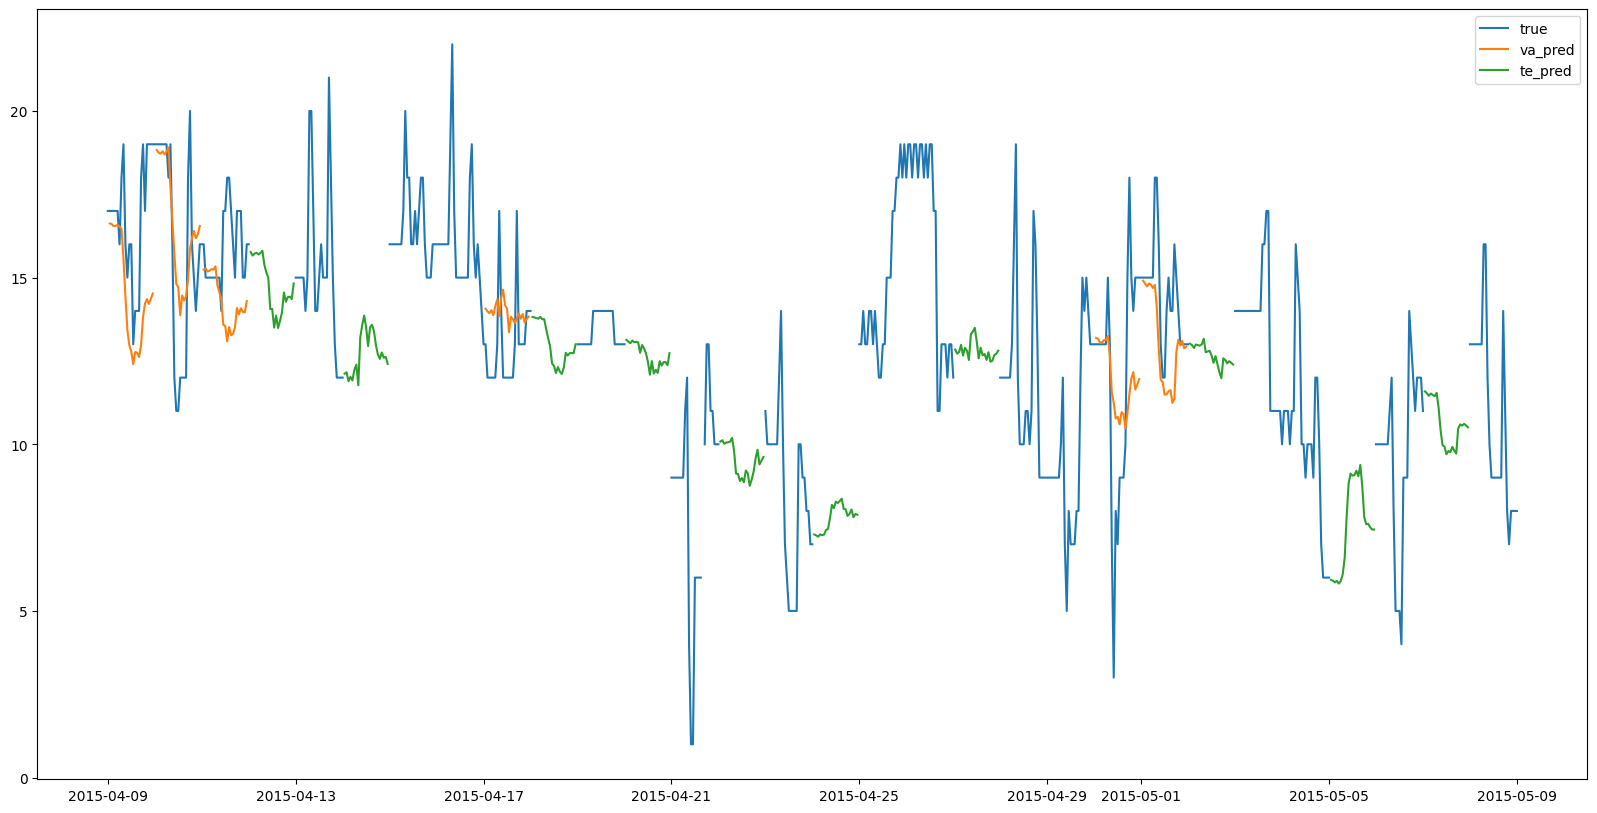

In [116]:
print(memo)
# datetimeを連続にする
df_ = pd.merge(df_true, df_va_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_va_pred"))
df_ = pd.merge(df_, df_te_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_te_pred"))
# データ期間,station_idを指定する
station_id = 0
start_date = "2015-04-09"
end_date = "2015-05-09"
df_ = df_[df_["station_id"]==station_id]
df_ = df_[(df_["datetime"] >= start_date) & (df_["datetime"] <= end_date)]
# プロット
plt.figure(figsize=(20, 10))
plt.plot(df_["datetime"], df_["bikes_available"], label="true")
plt.plot(df_["datetime"], df_["bikes_available_va_pred"], label="va_pred")
plt.plot(df_["datetime"], df_["bikes_available_te_pred"], label="te_pred")
plt.legend()
plt.show()

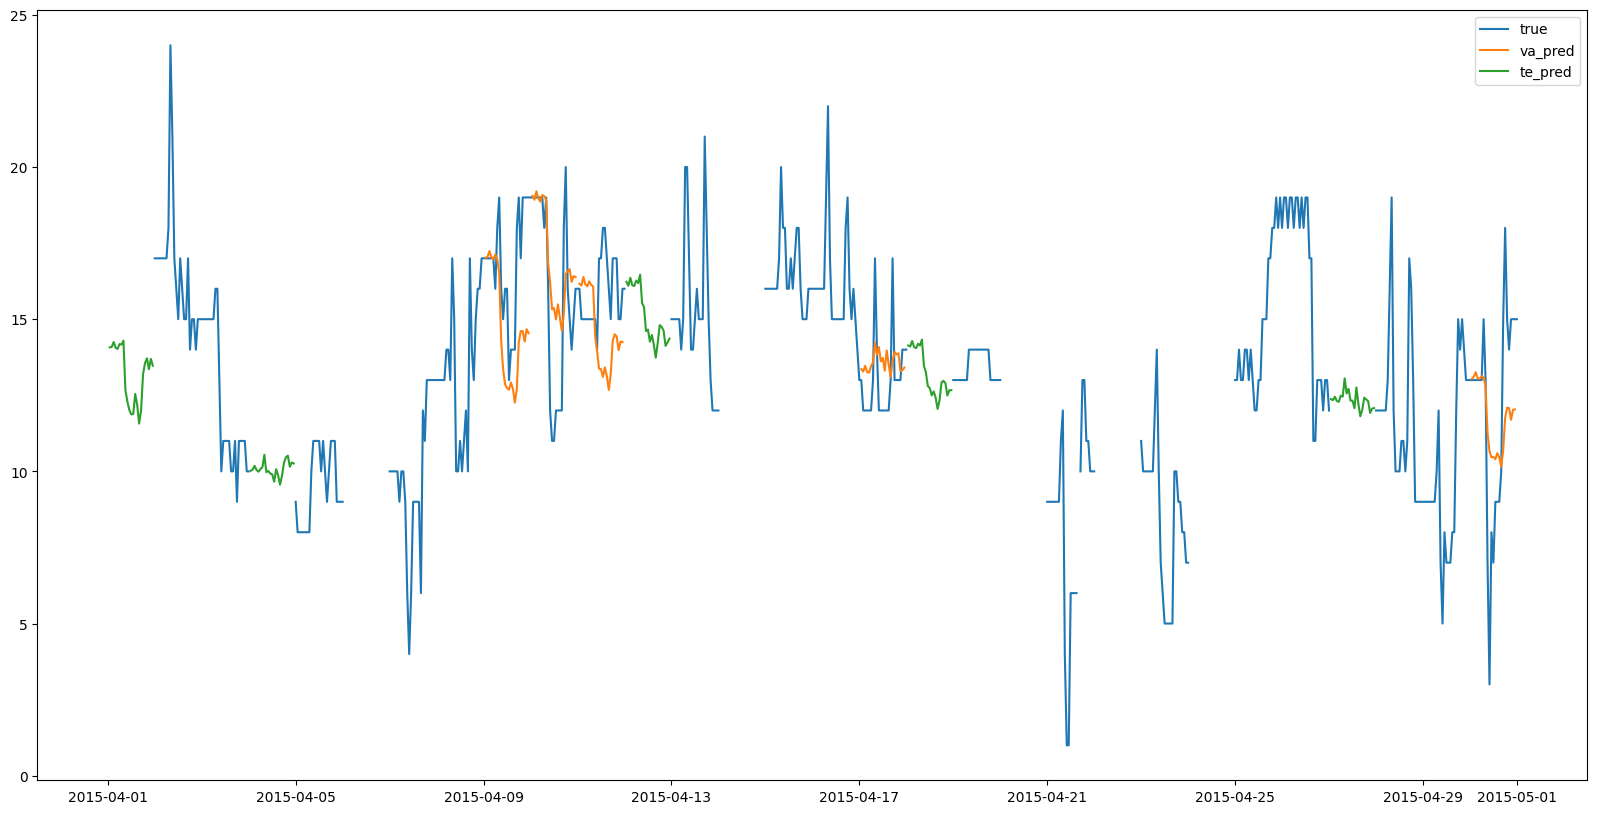

In [198]:
print(memo)
# datetimeを連続にする
df_ = pd.merge(df_true, df_va_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_va_pred"))
df_ = pd.merge(df_, df_te_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_te_pred"))
# データ期間,station_idを指定する
station_id = 0
start_date = "2015-04-01"
end_date = "2015-05-01"
df_ = df_[df_["station_id"]==station_id]
df_ = df_[(df_["datetime"] >= start_date) & (df_["datetime"] <= end_date)]
# プロット
plt.figure(figsize=(20, 10))
plt.plot(df_["datetime"], df_["bikes_available"], label="true")
plt.plot(df_["datetime"], df_["bikes_available_va_pred"], label="va_pred")
plt.plot(df_["datetime"], df_["bikes_available_te_pred"], label="te_pred")
plt.legend()
plt.show()

In [86]:
# データ数の変化
for month in range(8, 13):
    i_fold = datetime(2014, month, 1)
    tr, tr_va_te, list_va_date, list_te_date = runner.craete_train_valid_dateset(i_fold)
    model_ = model_LSTM_mult("sample", model_params, logger)
    self = model_
    feat_cols = [col for col in tr.columns.to_list() if col not in self.key_cols]
    x, y, list_key = self.create_sequences_for_forecast(tr, self.key_cols, feat_cols, self.seq_length, self.n_steps)
    print(i_fold, x.shape)

for month in range(1, 9):
    i_fold = datetime(2015, month, 1)
    tr, tr_va_te, list_va_date, list_te_date = runner.craete_train_valid_dateset(i_fold)
    model_ = model_LSTM_mult("sample", model_params, logger)
    self = model_
    feat_cols = [col for col in tr.columns.to_list() if col not in self.key_cols]
    x, y, list_key = self.create_sequences_for_forecast(tr, self.key_cols, feat_cols, self.seq_length, self.n_steps)
    print(i_fold, x.shape)

2014-08-01 00:00:00 (22406, 24, 2)
2014-09-01 00:00:00 (24576, 24, 2)
2014-10-01 00:00:00 (25276, 24, 2)


KeyboardInterrupt: 

In [83]:
# xの欠損値を確認
print(x.shape)
print(np.isnan(x).sum())
print(np.isnan(y).sum())

(24926, 48, 2)
0
0


In [87]:
# xの欠損値を確認
print(x.shape)
print(np.isnan(x).sum())
print(np.isnan(y).sum())

(25276, 24, 2)
0
0


# Submissionの作成

In [157]:
path_te_pred = os.path.join(runner.out_dir_name, "te_pred.pkl")
df_te_pred = pd.read_pickle(path_te_pred)
df_prep_status = pd.read_pickle(os.path.join(DIR_INTERIM, "df_prep_status.pkl"))[["id", "datetime", "station_id", "predict"]]

In [158]:
df_submit = pd.merge(df_prep_status, df_te_pred, on=["datetime", "station_id"], how="left")

In [159]:
df_submit[df_submit["predict"] == 1][["id", "bikes_available"]]

,id,bikes_available
8761,8761,15.073997
8762,8762,15.041523
8763,8763,15.065933
8764,8764,15.097093
8765,8765,15.107909
...,...,...
1226347,1226347,11.030661
1226348,1226348,10.902891
1226349,1226349,10.866402
1226350,1226350,10.792340


In [160]:
df_sample_submit = pd.read_csv(os.path.join(DIR_INPUT, "sample_submit.csv"), header=None, names=["id", "b_a"])

In [161]:
df_submit = pd.merge(df_sample_submit, df_submit, on=["id"], how="left")[["id", "bikes_available"]]

In [162]:
df_submit.isnull().sum()

id                 0
bikes_available    0
dtype: int64

In [164]:
path_submit = os.path.join(DIR_SUBMISSION, f"{runner.run_name}_submit.csv")
df_submit.to_csv(path_submit, header=False, index=False)

In [165]:
pd.read_csv(path_submit, header=None)

,0,1
0,8761,15.073998
1,8762,15.041523
2,8763,15.065933
3,8764,15.097093
4,8765,15.107909
...,...,...
193195,1226347,11.030661
193196,1226348,10.902891
193197,1226349,10.866402
193198,1226350,10.792340
